# Predict & Retain: Data-Driven HR Employee Attrition & Workforce Analytics
### Comprehensive Exploratory Data Analysis & Strategic Workforce Insights

---
## 1. Project Introduction
Employee attrition represents one of the most critical challenges confronting modern organizations. Unplanned departures disrupt ongoing operations, diminish institutional knowledge, elevate recruitment and onboarding costs, and impact workforce morale. 

In this project, titled **Predict & Retain**, we employ systematic data science and statistical methodology to investigate the underlying organizational, financial, and personal drivers that associate with employee turnover.


## 2. Problem Statement
Human resources leadership requires empirical, data-grounded insights into workforce dynamics rather than anecdotal assumptions. Specifically, organizational leadership seeks to understand:
* Which business divisions and job titles experience elevated turnover rates?
* How does compensation disparities correlate with attrition across different tenure levels and job roles?
* What measurable role do workplace stress indicators—namely mandatory overtime and lengthy daily commutes—play in employee retention?
* How do employee subjective metrics such as job satisfaction and work-life balance interact to influence turnover behavior?


## 3. Project Objectives
1. **Quantify Attrition Risk:** Measure baseline and segment-specific attrition across business divisions (Research & Development, Sales, Human Resources) and nine distinct job roles.
2. **Compensation Architecture Analysis:** Evaluate monthly income distributions, mean/median comparisons, and statistical significance tests between departing and retained staff.
3. **Workplace Stress & Well-Being Evaluation:** Analyze the observational relationships between overtime status, commute distance from home, work-life balance, and turnover.
4. **Interactive Analytics & Decision Support:** Prepare engineered feature sets, statistical matrices, and a clean analytical dataset (`final_dataset.csv`) to power business intelligence dashboards.


## 4. Dataset Source & Attribution
The dataset utilized in this investigation is the widely studied **IBM HR Analytics Employee Attrition & Performance** dataset, originally created by data scientists at IBM.
* **Total Records:** 1,470 employee entries
* **Total Variables:** 35 initial workforce attributes
* **Domain:** Demographics, compensation, tenure, job roles, performance ratings, and survey responses.


## 5. Import Libraries
We import Python's scientific computing, visualization, and statistical modeling libraries.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress minor warnings for clean report generation
warnings.filterwarnings('ignore')

# Set plotting aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries imported successfully!")


Libraries imported successfully!


## 6. Load Dataset
We load the raw workforce records from `data/original_dataset.csv`.


In [2]:
raw_data_path = os.path.join('..', 'data', 'original_dataset.csv')
if not os.path.exists(raw_data_path):
    raw_data_path = os.path.join('data', 'original_dataset.csv')

df_raw = pd.read_csv(raw_data_path)
print(f"Loaded dataset successfully with shape: {df_raw.shape}")


Loaded dataset successfully with shape: (1470, 35)


## 7. Dataset Overview
We inspect the structure, first and last records, and data types of the loaded records.


In [3]:
# Display dataset head
df_raw.head(5)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Display shape and column listing
print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nColumns in Dataset:")
print(list(df_raw.columns))


Dataset Dimensions: 1470 rows, 35 columns

Columns in Dataset:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 8. Data Understanding & Summary Statistics
We inspect the comprehensive data summary, information schema, and numerical distribution metrics.


In [5]:
# DataFrame info summary
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Numerical feature distribution summary
df_raw.describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0


## 9. Data Cleaning Pipeline
Before conducting analytical investigations, we rigorously verify data integrity:
1. Detect missing or null values across all features
2. Check for duplicate employee records
3. Audit constant / zero-variance administrative features (e.g., `EmployeeCount`, `StandardHours`, `Over18`)
4. Inspect potential data entry anomalies and extreme values


In [7]:
# Missing value evaluation
null_counts = df_raw.isnull().sum()
total_nulls = null_counts.sum()
print(f"Total missing values across entire dataset: {total_nulls}")
if total_nulls > 0:
    print(null_counts[null_counts > 0])
else:
    print("Zero missing values detected. All 1,470 records are complete.")

# Duplicate records evaluation
duplicate_count = df_raw.duplicated().sum()
print(f"Total duplicate records detected: {duplicate_count}")


Total missing values across entire dataset: 0
Zero missing values detected. All 1,470 records are complete.
Total duplicate records detected: 0


In [8]:
# Audit zero-variance / constant columns
constant_cols = [col for col in df_raw.columns if df_raw[col].nunique() <= 1]
print(f"Constant/Zero-variance features identified: {constant_cols}")
for col in constant_cols:
    print(f" - {col}: constant value = {df_raw[col].iloc[0]}")


Constant/Zero-variance features identified: ['EmployeeCount', 'Over18', 'StandardHours']
 - EmployeeCount: constant value = 1
 - Over18: constant value = Y
 - StandardHours: constant value = 80


## 10. Data Transformation
We create a clean working copy of the dataset and standardize categorical attributes.


In [9]:
# Create clean analytical DataFrame
df_clean = df_raw.copy()

# Validate categorical fields
categorical_cols = ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
for col in categorical_cols:
    print(f"{col} categories ({df_clean[col].nunique()}): {df_clean[col].unique().tolist()}")


Attrition categories (2): ['Yes', 'No']
BusinessTravel categories (3): ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Department categories (3): ['Sales', 'Research & Development', 'Human Resources']
EducationField categories (6): ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
Gender categories (2): ['Female', 'Male']
JobRole categories (9): ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
MaritalStatus categories (3): ['Single', 'Married', 'Divorced']
OverTime categories (2): ['Yes', 'No']


## 11. Feature Engineering
As specified in the analytical guidelines, we engineer essential operational features:
1. `Attrition_Num`: Binary numerical mapping (`Yes` -> 1, `No` -> 0)
2. `TenureRatio`: Ratio of years spent at the company relative to chronological age (`YearsAtCompany / Age`)
3. `TenureGroup`: Categorical tenure bands (`0-2 years`, `3-5 years`, `6-10 years`, `11+ years`)
4. `DistanceBand`: Commute distance groups (`0-5 km`, `6-10 km`, `11-20 km`, `21+ km`)


In [10]:
# 1. Attrition_Num binary indicator
df_clean['Attrition_Num'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0}).astype(int)

# 2. TenureRatio with safe denominator validation
df_clean['TenureRatio'] = np.where(df_clean['Age'] > 0, (df_clean['YearsAtCompany'] / df_clean['Age']).round(4), 0.0)

# 3. TenureGroup categorization
df_clean['TenureGroup'] = pd.cut(
    df_clean['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 100],
    labels=['0-2 years', '3-5 years', '6-10 years', '11+ years']
).astype(str)

# 4. DistanceBand categorization
df_clean['DistanceBand'] = pd.cut(
    df_clean['DistanceFromHome'],
    bins=[-1, 5, 10, 20, 100],
    labels=['0-5 km', '6-10 km', '11-20 km', '21+ km']
).astype(str)

print("Engineered features preview:")
df_clean[['Attrition', 'Attrition_Num', 'Age', 'YearsAtCompany', 'TenureRatio', 'TenureGroup', 'DistanceFromHome', 'DistanceBand']].head()


Engineered features preview:


,Attrition,Attrition_Num,Age,YearsAtCompany,TenureRatio,TenureGroup,DistanceFromHome,DistanceBand
0,Yes,1,41,6,0.1463,6-10 years,1,0-5 km
1,No,0,49,10,0.2041,6-10 years,8,6-10 km
2,Yes,1,37,0,0.0000,0-2 years,2,0-5 km
3,No,0,33,8,0.2424,6-10 years,3,0-5 km
4,No,0,27,2,0.0741,0-2 years,2,0-5 km


## 12. Exploratory Data Analysis (EDA)
With clean and engineered variables in place, we proceed to answer each fundamental workforce retention question programmatically.


## 13. Overall Attrition Analysis
We compute the baseline workforce retention and turnover counts.


In [11]:
total_workforce = len(df_clean)
attrition_counts = df_clean['Attrition'].value_counts()
attrition_rates = df_clean['Attrition'].value_counts(normalize=True) * 100

overall_departed = int(attrition_counts.get('Yes', 0))
overall_retained = int(attrition_counts.get('No', 0))
overall_attrition_rate = attrition_rates.get('Yes', 0.0)

print(f"Total Employees: {total_workforce:,}")
print(f"Retained Employees: {overall_retained:,} ({attrition_rates['No']:.2f}%)")
print(f"Departed Employees: {overall_departed:,} ({overall_attrition_rate:.2f}%)")


Total Employees: 1,470
Retained Employees: 1,233 (83.88%)
Departed Employees: 237 (16.12%)


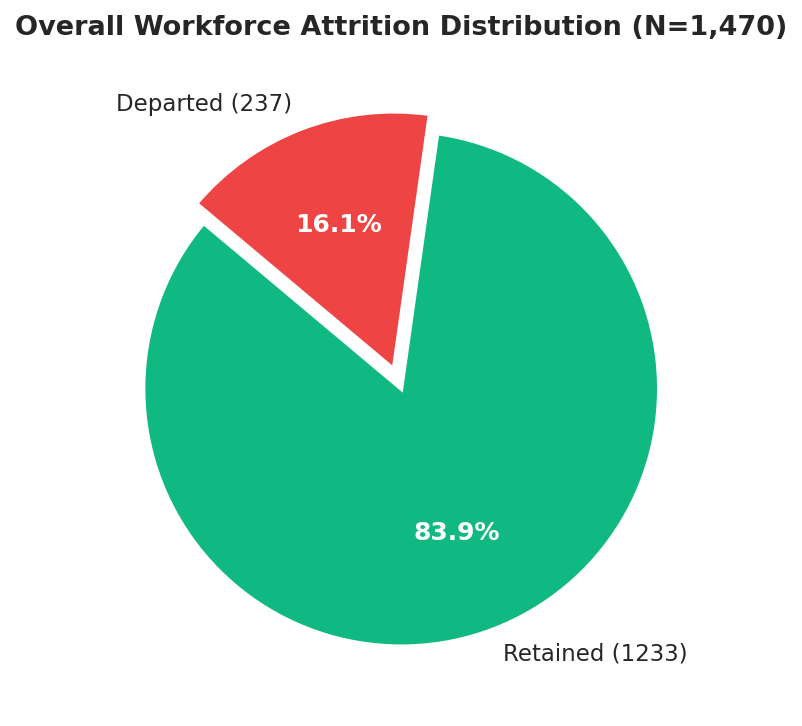

In [12]:
# Visualization: Overall Attrition Distribution
fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#10B981', '#EF4444']
wedges, texts, autotexts = ax.pie(
    [overall_retained, overall_departed],
    labels=[f'Retained ({overall_retained})', f'Departed ({overall_departed})'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    explode=[0, 0.08],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('white')
    at.set_weight('bold')
ax.set_title('Overall Workforce Attrition Distribution (N=1,470)', pad=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. Departmental Attrition Analysis
We evaluate employee distribution, departure count, and observed attrition rates across Research & Development, Sales, and Human Resources.


In [13]:
dept_analysis = df_clean.groupby('Department').agg(
    Total_Headcount=('Attrition', 'count'),
    Departures=('Attrition_Num', 'sum'),
    Attrition_Rate=('Attrition_Num', 'mean')
)
dept_analysis['Attrition_Rate%'] = (dept_analysis['Attrition_Rate'] * 100).round(2)
dept_analysis.sort_values(by='Attrition_Rate%', ascending=False)


,Total_Headcount,Departures,Attrition_Rate,Attrition_Rate%
Department,,,,
Sales,446,92,0.206278,20.63
Human Resources,63,12,0.190476,19.05
Research & Development,961,133,0.138398,13.84


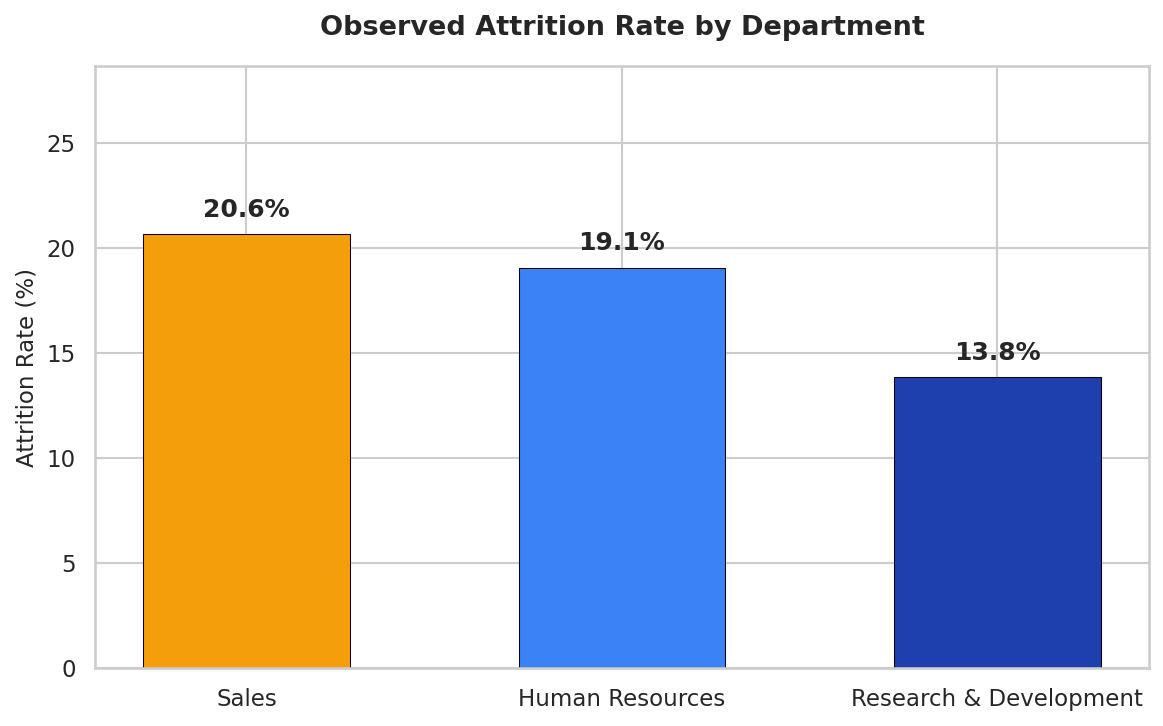

In [14]:
# Visualization: Attrition Rate by Department
fig, ax = plt.subplots(figsize=(8, 5))
dept_plot = dept_analysis.reset_index().sort_values(by='Attrition_Rate%', ascending=False)
bars = ax.bar(dept_plot['Department'], dept_plot['Attrition_Rate%'], color=['#F59E0B', '#3B82F6', '#1E40AF'], width=0.55, edgecolor='black', linewidth=0.5)
ax.set_title('Observed Attrition Rate by Department', pad=15, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, max(dept_plot['Attrition_Rate%']) + 8)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.6, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 15. Job Role Attrition Analysis
We analyze turnover variations across the nine organizational job roles.


In [15]:
role_analysis = df_clean.groupby('JobRole').agg(
    Total_Employees=('Attrition', 'count'),
    Departures=('Attrition_Num', 'sum'),
    Attrition_Rate=('Attrition_Num', 'mean'),
    Avg_Monthly_Income=('MonthlyIncome', 'mean'),
    Median_Monthly_Income=('MonthlyIncome', 'median')
)
role_analysis['Attrition_Rate%'] = (role_analysis['Attrition_Rate'] * 100).round(2)
role_analysis['Avg_Monthly_Income'] = role_analysis['Avg_Monthly_Income'].round(2)
role_analysis.sort_values(by='Attrition_Rate%', ascending=False)


,Total_Employees,Departures,Attrition_Rate,Avg_Monthly_Income,Median_Monthly_Income,Attrition_Rate%
JobRole,,,,,,
Sales Representative,83,33,0.397590,2626.00,2579.0,39.76
Laboratory Technician,259,62,0.239382,3237.17,2886.0,23.94
Human Resources,52,12,0.230769,4235.75,3093.0,23.08
Sales Executive,326,57,0.174847,6924.28,6231.0,17.48
Research Scientist,292,47,0.160959,3239.97,2887.5,16.10
Manufacturing Director,145,10,0.068966,7295.14,6447.0,6.90
Healthcare Representative,131,9,0.068702,7528.76,6811.0,6.87
Manager,102,5,0.049020,17181.68,17454.5,4.90
Research Director,80,2,0.025000,16033.55,16510.0,2.50


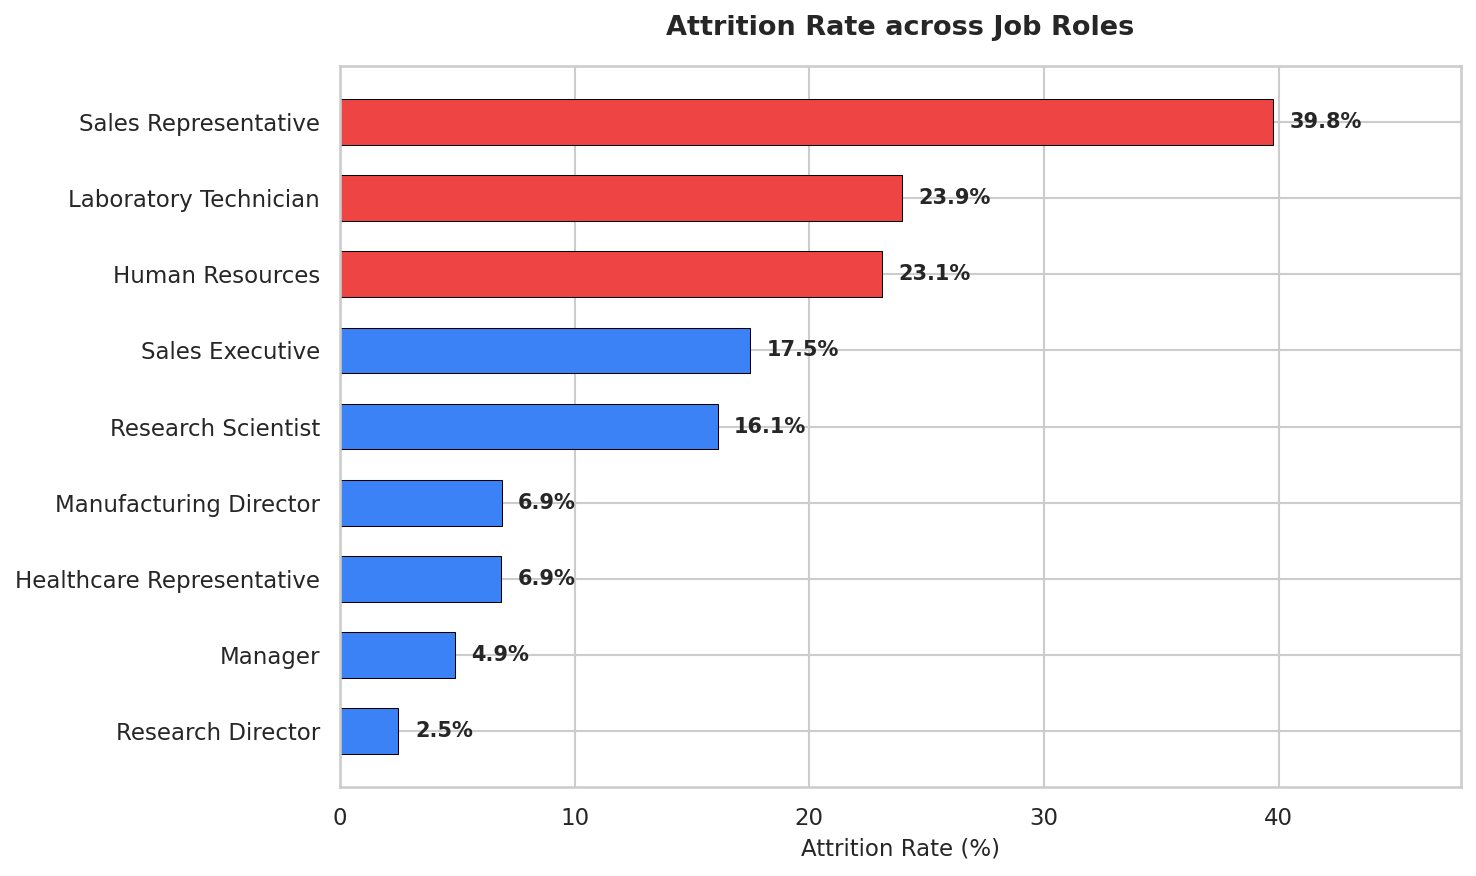

In [16]:
# Visualization: Job Role Turnover
fig, ax = plt.subplots(figsize=(10, 6))
role_sorted = role_analysis.reset_index().sort_values(by='Attrition_Rate%', ascending=True)
colors = ['#EF4444' if r > 20 else '#3B82F6' for r in role_sorted['Attrition_Rate%']]
bars = ax.barh(role_sorted['JobRole'], role_sorted['Attrition_Rate%'], color=colors, height=0.6, edgecolor='black', linewidth=0.5)
ax.set_title('Attrition Rate across Job Roles', pad=15, fontweight='bold')
ax.set_xlabel('Attrition Rate (%)')
ax.set_xlim(0, max(role_sorted['Attrition_Rate%']) + 8)

for bar in bars:
    xval = bar.get_width()
    ax.text(xval + 0.7, bar.get_y() + bar.get_height()/2.0, f'{xval:.1f}%', ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


## 16. Overtime Impact & Statistical Association
We evaluate whether working overtime demonstrates a statistically significant association with employee attrition.


In [17]:
ot_analysis = df_clean.groupby('OverTime').agg(
    Total_Headcount=('Attrition', 'count'),
    Departures=('Attrition_Num', 'sum'),
    Attrition_Rate=('Attrition_Num', 'mean')
)
ot_analysis['Attrition_Rate%'] = (ot_analysis['Attrition_Rate'] * 100).round(2)
ot_analysis


,Total_Headcount,Departures,Attrition_Rate,Attrition_Rate%
OverTime,,,,
No,1054,110,0.104364,10.44
Yes,416,127,0.305288,30.53


In [18]:
# Chi-square test of independence
contingency_table = pd.crosstab(df_clean['OverTime'], df_clean['Attrition'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("Contingency Table (OverTime vs Attrition):")
print(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: Statistically significant association between OverTime and Attrition (p < 0.05).")
    print("Observational interpretation: Employees who work overtime demonstrate significantly higher observed turnover rates.")
else:
    print("Conclusion: No statistically significant association observed.")


Contingency Table (OverTime vs Attrition):
Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

Chi-Square Statistic: 87.5643
Degrees of Freedom: 1
p-value: 8.1584e-21
Conclusion: Statistically significant association between OverTime and Attrition (p < 0.05).
Observational interpretation: Employees who work overtime demonstrate significantly higher observed turnover rates.


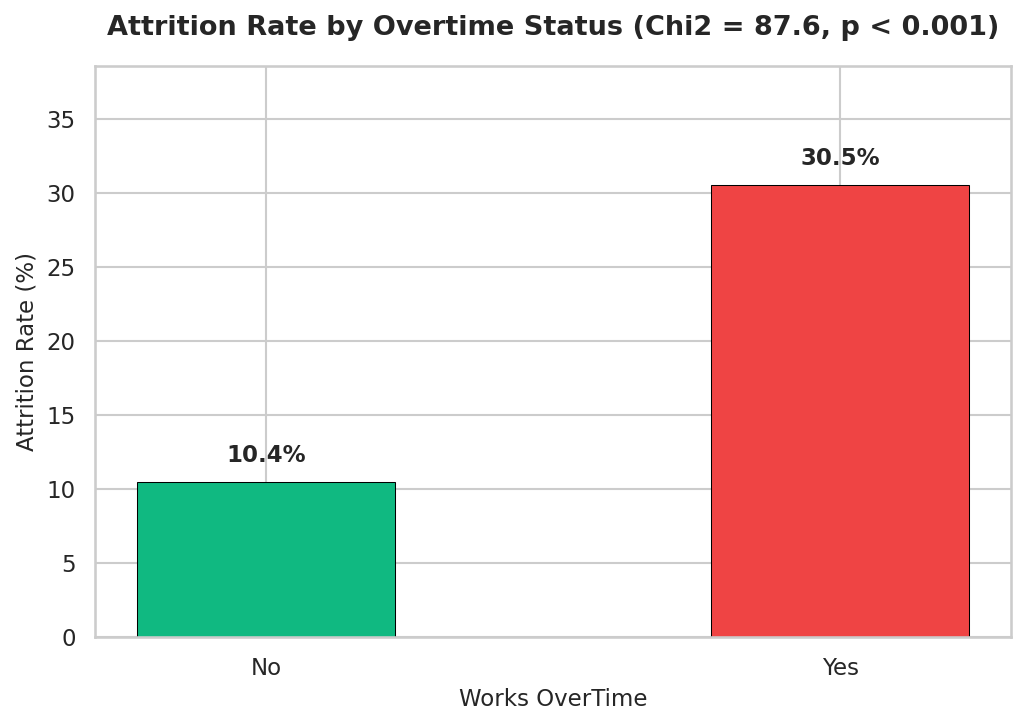

In [19]:
# Visualization: Overtime Attrition Comparison
fig, ax = plt.subplots(figsize=(7, 5))
ot_df = ot_analysis.reset_index()
bars = ax.bar(ot_df['OverTime'], ot_df['Attrition_Rate%'], color=['#10B981', '#EF4444'], width=0.45, edgecolor='black', linewidth=0.5)
ax.set_title(f'Attrition Rate by Overtime Status (Chi2 = {chi2:.1f}, p < 0.001)', pad=15, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Works OverTime')
ax.set_ylim(0, max(ot_df['Attrition_Rate%']) + 8)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.0, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## 17. Compensation & Salary Analysis
We compute compensation metrics for retained versus departing employees, including mean, median, distributions, and inferential t-tests.


In [20]:
income_stats = df_clean.groupby('Attrition')['MonthlyIncome'].agg(
    Headcount='count',
    Mean_Income='mean',
    Median_Income='median',
    Std_Dev='std',
    Min_Income='min',
    Max_Income='max'
).round(2)
income_stats


,Headcount,Mean_Income,Median_Income,Std_Dev,Min_Income,Max_Income
Attrition,,,,,,
No,1233,6832.74,5204.0,4818.21,1051,19999
Yes,237,4787.09,3202.0,3640.21,1009,19859


In [21]:
# Independent samples t-test (Welch's t-test allowing unequal variances)
income_stayed = df_clean[df_clean['Attrition'] == 'No']['MonthlyIncome']
income_left = df_clean[df_clean['Attrition'] == 'Yes']['MonthlyIncome']

t_stat, p_val_inc = stats.ttest_ind(income_left, income_stayed, equal_var=False)
mean_diff = income_stayed.mean() - income_left.mean()
median_diff = income_stayed.median() - income_left.median()

print(f"Mean Monthly Income Gap: ${mean_diff:,.2f} (Retained > Departed)")
print(f"Median Monthly Income Gap: ${median_diff:,.2f} (Retained > Departed)")
print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"p-value: {p_val_inc:.4e}")


Mean Monthly Income Gap: $2,045.65 (Retained > Departed)
Median Monthly Income Gap: $2,002.00 (Retained > Departed)
Welch's t-test statistic: -7.4826
p-value: 4.4336e-13


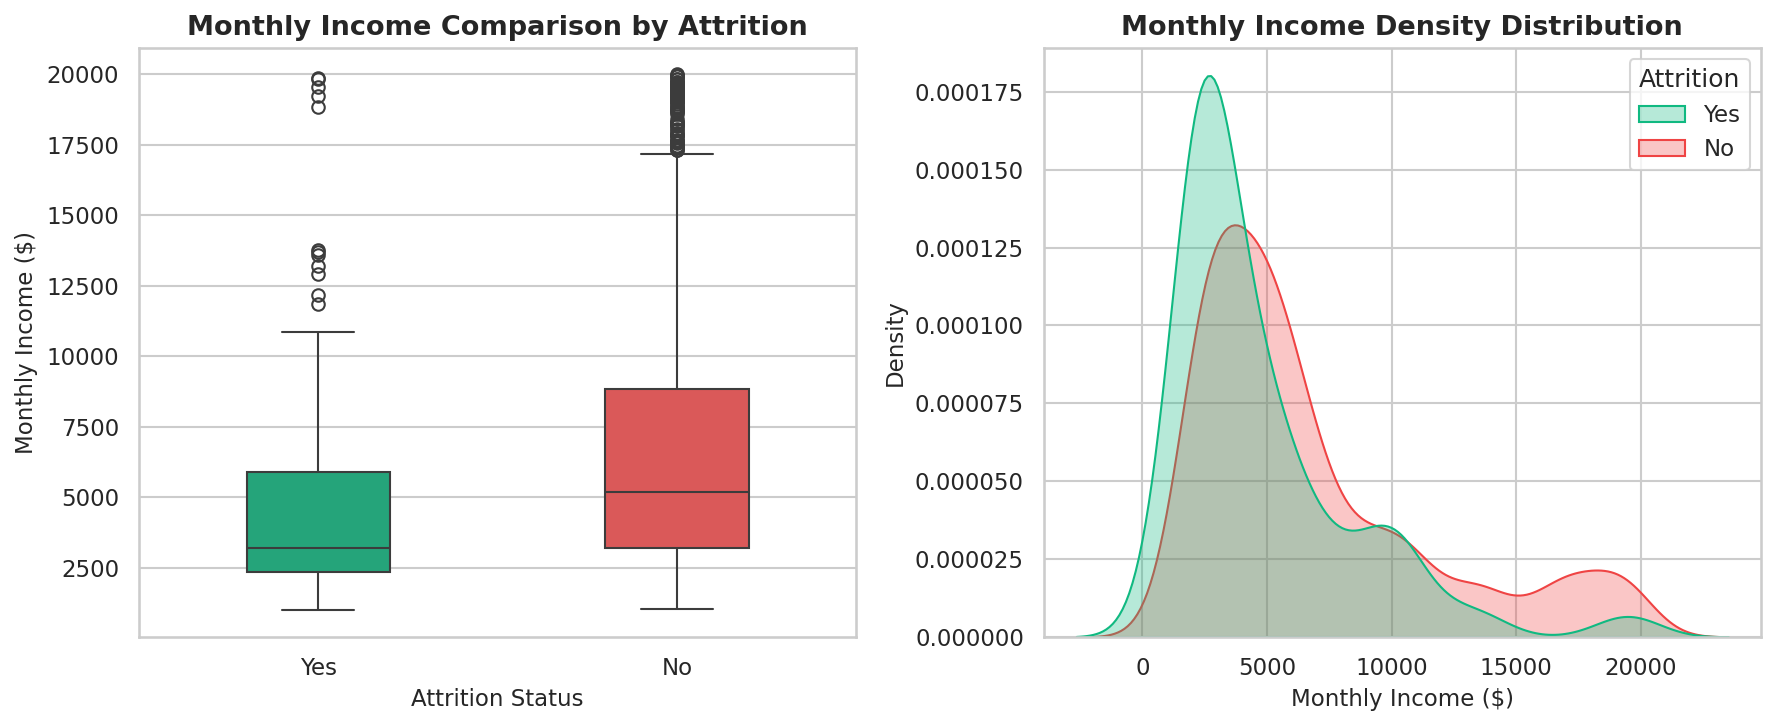

In [22]:
# Visualization: Monthly Income Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, palette=['#10B981', '#EF4444'], ax=ax1, width=0.4)
ax1.set_title('Monthly Income Comparison by Attrition', fontweight='bold')
ax1.set_ylabel('Monthly Income ($)')
ax1.set_xlabel('Attrition Status')

# KDE Density Plot
sns.kdeplot(data=df_clean, x='MonthlyIncome', hue='Attrition', palette=['#10B981', '#EF4444'], common_norm=False, fill=True, alpha=0.3, ax=ax2)
ax2.set_title('Monthly Income Density Distribution', fontweight='bold')
ax2.set_xlabel('Monthly Income ($)')

plt.tight_layout()
plt.show()


## 18. Tenure Dynamics & TenureRatio Analysis
We investigate employee longevity at the company and examine how `YearsAtCompany` and `TenureRatio` associate with turnover risk.


In [23]:
tenure_stats = df_clean.groupby('TenureGroup', observed=False).agg(
    Total_Employees=('Attrition', 'count'),
    Departures=('Attrition_Num', 'sum'),
    Attrition_Rate=('Attrition_Num', 'mean'),
    Avg_Monthly_Income=('MonthlyIncome', 'mean')
)
tenure_stats['Attrition_Rate%'] = (tenure_stats['Attrition_Rate'] * 100).round(2)
tenure_stats['Avg_Monthly_Income'] = tenure_stats['Avg_Monthly_Income'].round(2)
tenure_stats


,Total_Employees,Departures,Attrition_Rate,Avg_Monthly_Income,Attrition_Rate%
TenureGroup,,,,,
0-2 years,342,102,0.298246,4709.34,29.82
11+ years,246,20,0.081301,10886.87,8.13
3-5 years,434,60,0.138249,5364.89,13.82
6-10 years,448,55,0.122768,6567.37,12.28


In [24]:
# TenureRatio summary by Attrition Status
tr_stats = df_clean.groupby('Attrition')['TenureRatio'].agg(['count', 'mean', 'median', 'std']).round(4)
print("TenureRatio (YearsAtCompany / Age) Summary:")
print(tr_stats)


TenureRatio (YearsAtCompany / Age) Summary:
           count    mean  median     std
Attrition                               
No          1233  0.1956  0.1667  0.1418
Yes          237  0.1424  0.1000  0.1349


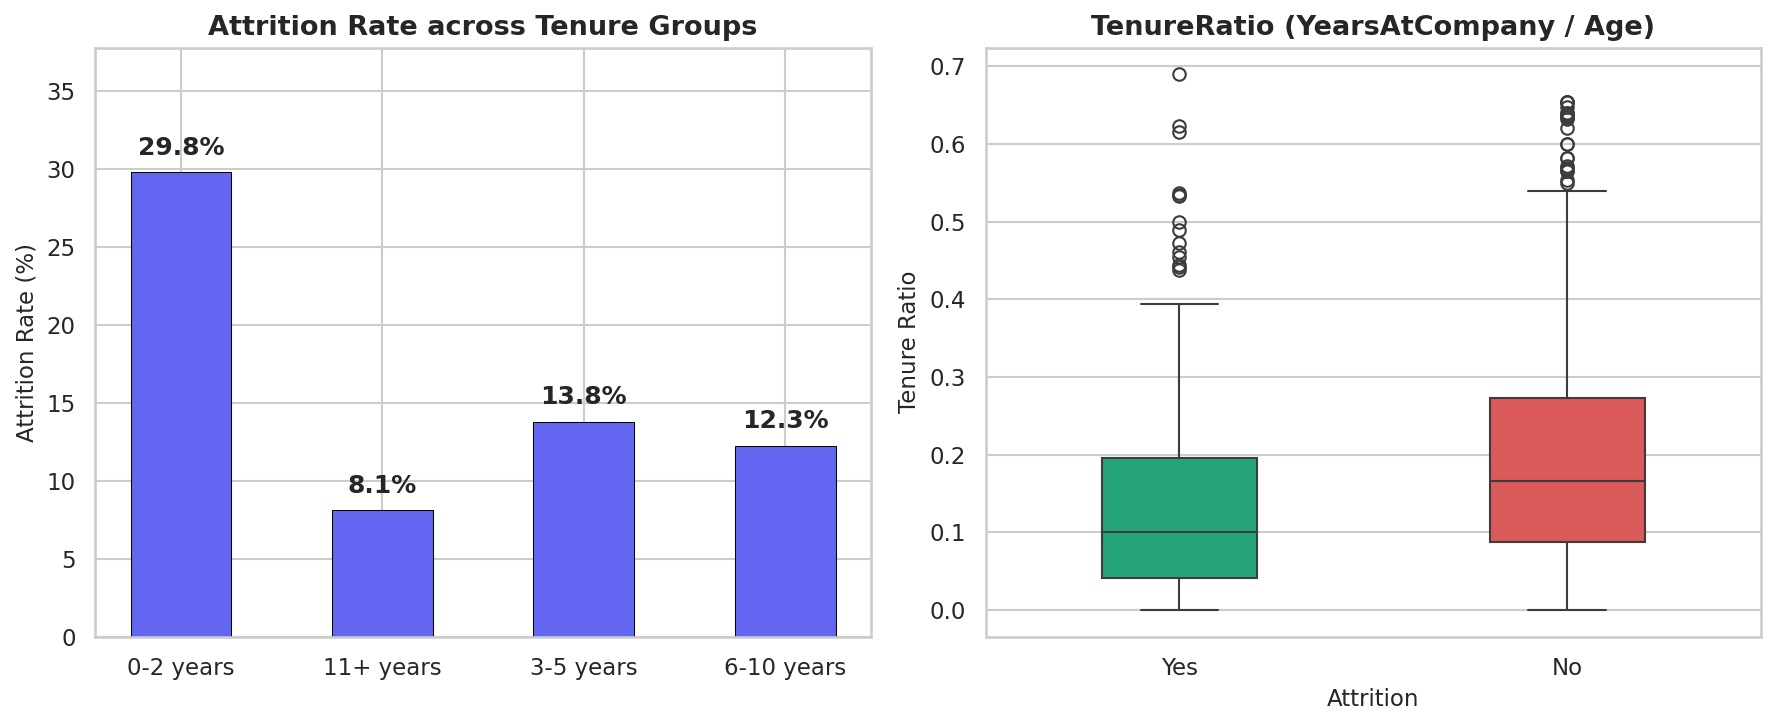

In [25]:
# Visualization: Tenure and TenureRatio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Attrition rate by Tenure Group
tg_plot = tenure_stats.reset_index()
bars = ax1.bar(tg_plot['TenureGroup'], tg_plot['Attrition_Rate%'], color='#6366F1', width=0.5, edgecolor='black', linewidth=0.5)
ax1.set_title('Attrition Rate across Tenure Groups', fontweight='bold')
ax1.set_ylabel('Attrition Rate (%)')
ax1.set_ylim(0, max(tg_plot['Attrition_Rate%']) + 8)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# TenureRatio Boxplot
sns.boxplot(x='Attrition', y='TenureRatio', data=df_clean, palette=['#10B981', '#EF4444'], ax=ax2, width=0.4)
ax2.set_title('TenureRatio (YearsAtCompany / Age)', fontweight='bold')
ax2.set_ylabel('Tenure Ratio')

plt.tight_layout()
plt.show()


## 19. Job Satisfaction & Work-Life Balance Analysis
We evaluate employee survey metrics rated on a 1 to 4 ordinal scale, both individually and in combination.


In [26]:
js_stats = df_clean.groupby('JobSatisfaction').agg(
    Headcount=('Attrition', 'count'),
    Departures=('Attrition_Num', 'sum'),
    Attrition_Rate=('Attrition_Num', 'mean')
)
js_stats['Attrition_Rate%'] = (js_stats['Attrition_Rate'] * 100).round(2)

wlb_stats = df_clean.groupby('WorkLifeBalance').agg(
    Headcount=('Attrition', 'count'),
    Departures=('Attrition_Num', 'sum'),
    Attrition_Rate=('Attrition_Num', 'mean')
)
wlb_stats['Attrition_Rate%'] = (wlb_stats['Attrition_Rate'] * 100).round(2)

print("Job Satisfaction Attrition Rates:")
print(js_stats)
print("\nWork-Life Balance Attrition Rates:")
print(wlb_stats)


Job Satisfaction Attrition Rates:
                 Headcount  Departures  Attrition_Rate  Attrition_Rate%
JobSatisfaction                                                        
1                      289          66        0.228374            22.84
2                      280          46        0.164286            16.43
3                      442          73        0.165158            16.52
4                      459          52        0.113290            11.33

Work-Life Balance Attrition Rates:
                 Headcount  Departures  Attrition_Rate  Attrition_Rate%
WorkLifeBalance                                                        
1                       80          25        0.312500            31.25
2                      344          58        0.168605            16.86
3                      893         127        0.142217            14.22
4                      153          27        0.176471            17.65


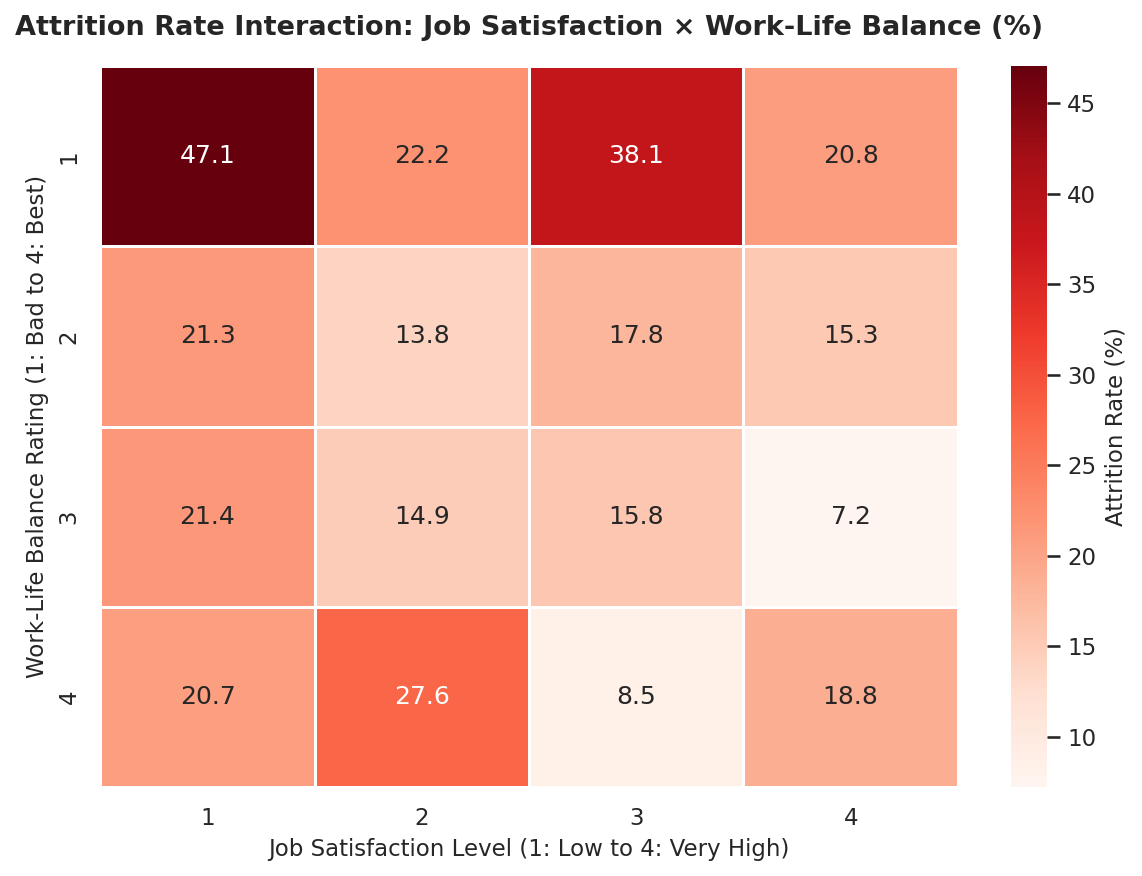

In [27]:
# Visualization: Combined Interaction Heatmap
cross_tab_heat = df_clean.pivot_table(
    index='WorkLifeBalance',
    columns='JobSatisfaction',
    values='Attrition_Num',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cross_tab_heat, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Attrition Rate (%)'}, ax=ax, linewidths=0.5)
ax.set_title('Attrition Rate Interaction: Job Satisfaction × Work-Life Balance (%)', pad=15, fontweight='bold')
ax.set_xlabel('Job Satisfaction Level (1: Low to 4: Very High)')
ax.set_ylabel('Work-Life Balance Rating (1: Bad to 4: Best)')
plt.tight_layout()
plt.show()


## 20. Distance from Home & Commute Analysis
We examine employee commute distances and test whether longer commutes relate to elevated attrition.


In [28]:
dist_stats = df_clean.groupby('DistanceBand', observed=False).agg(
    Total_Employees=('Attrition', 'count'),
    Departures=('Attrition_Num', 'sum'),
    Attrition_Rate=('Attrition_Num', 'mean'),
    Avg_Distance=('DistanceFromHome', 'mean')
)
dist_stats['Attrition_Rate%'] = (dist_stats['Attrition_Rate'] * 100).round(2)
dist_stats['Avg_Distance'] = dist_stats['Avg_Distance'].round(1)
dist_stats


,Total_Employees,Departures,Attrition_Rate,Avg_Distance,Attrition_Rate%
DistanceBand,,,,,
0-5 km,632,87,0.137658,2.3,13.77
11-20 km,240,48,0.200000,15.5,20.00
21+ km,204,45,0.220588,25.1,22.06
6-10 km,394,57,0.144670,8.1,14.47


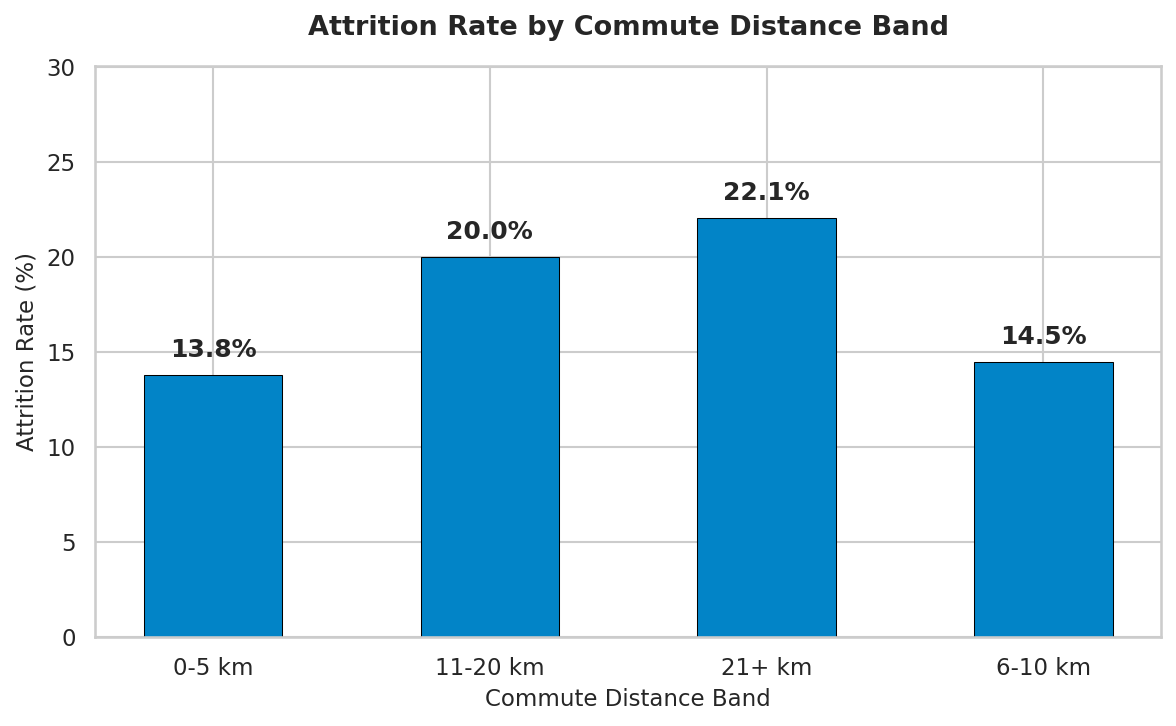

In [29]:
# Visualization: Distance Bands Attrition
fig, ax = plt.subplots(figsize=(8, 5))
db_plot = dist_stats.reset_index()
bars = ax.bar(db_plot['DistanceBand'], db_plot['Attrition_Rate%'], color='#0284C7', width=0.5, edgecolor='black', linewidth=0.5)
ax.set_title('Attrition Rate by Commute Distance Band', pad=15, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Commute Distance Band')
ax.set_ylim(0, max(db_plot['Attrition_Rate%']) + 8)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.7, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 21. Correlation Analysis
We construct a numeric correlation matrix encompassing demographic, organizational, and engineered features.


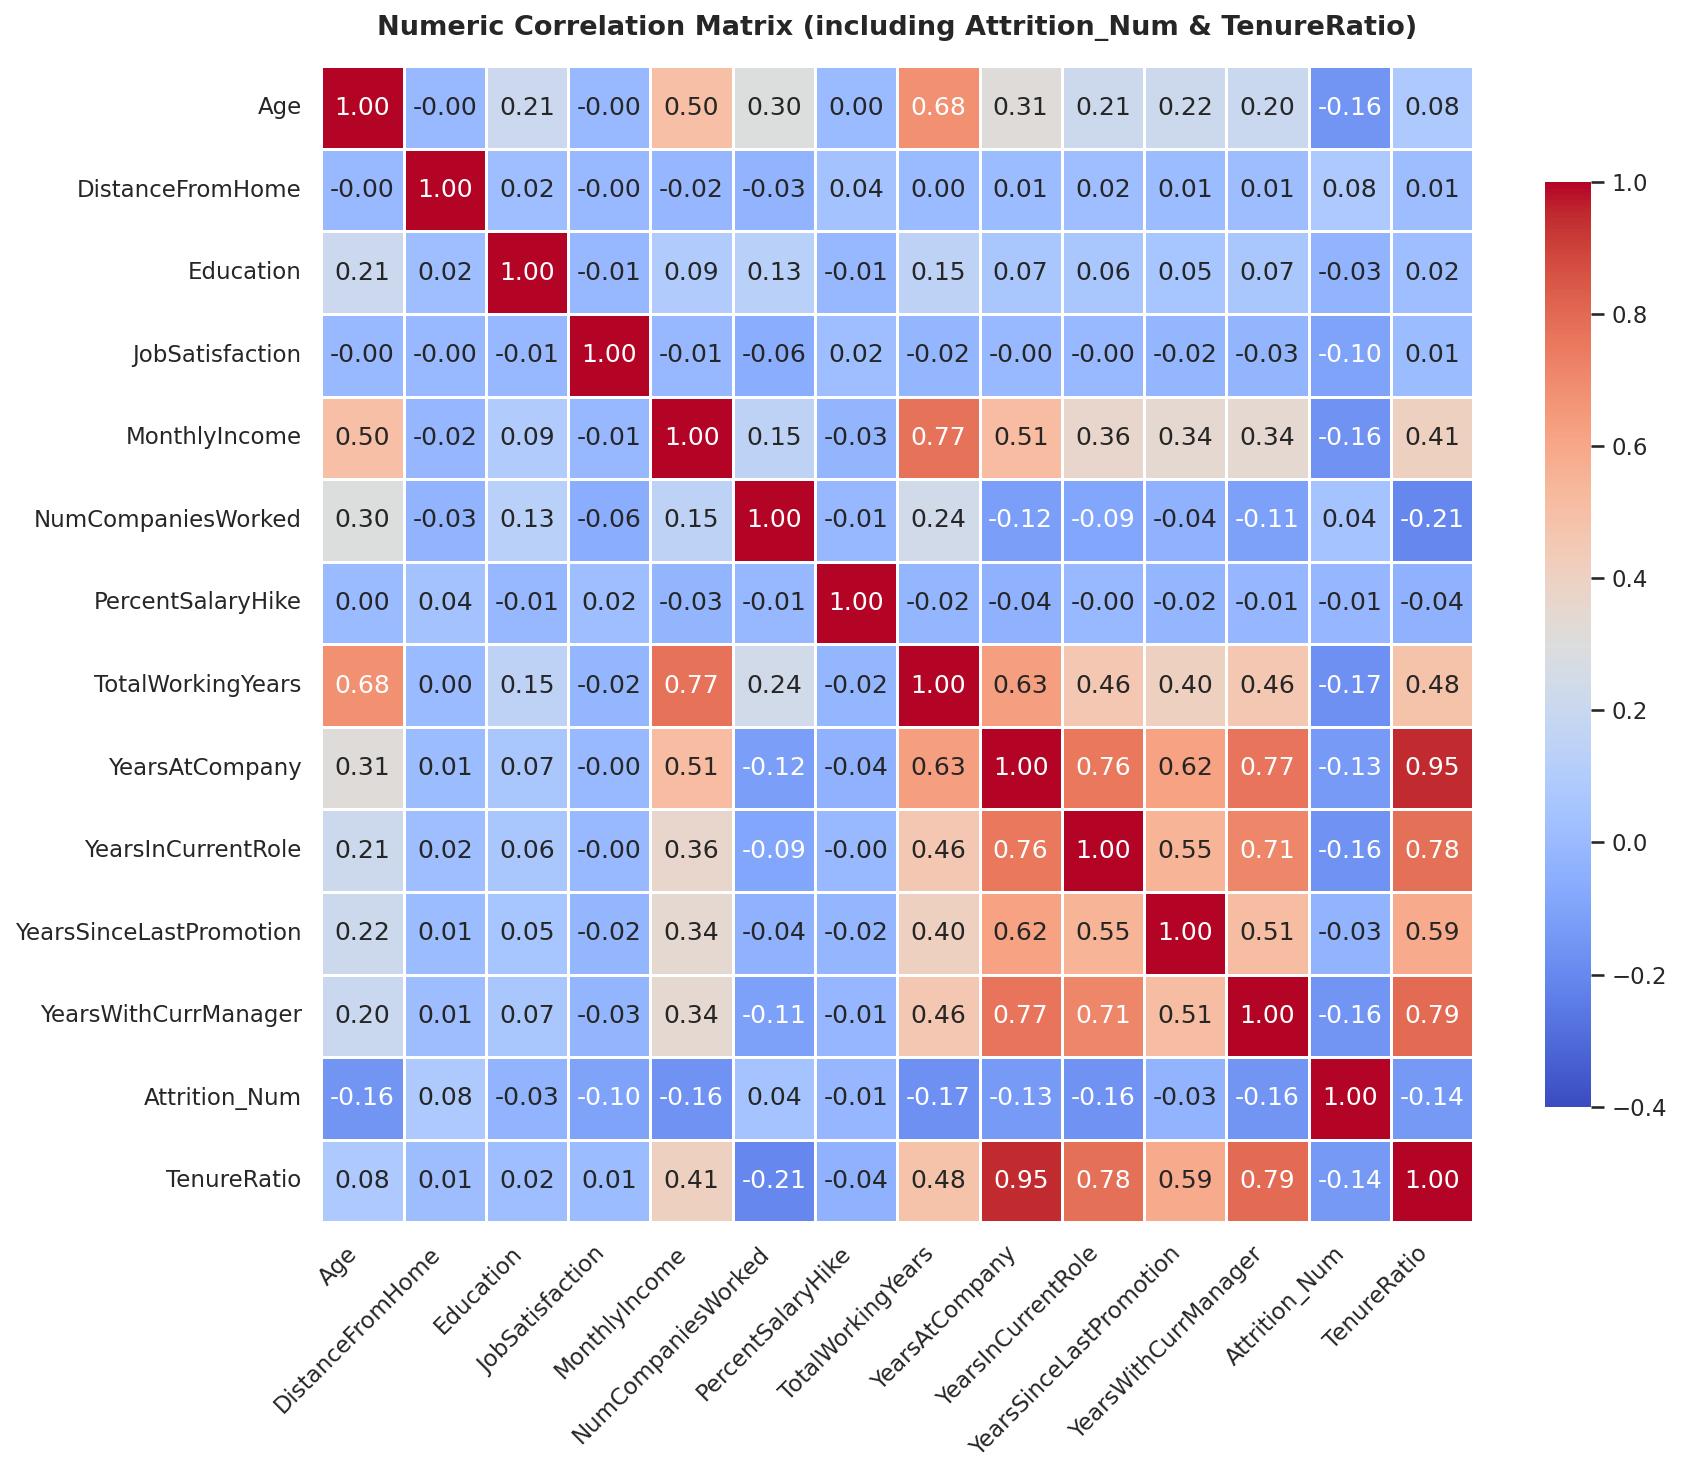

In [30]:
corr_cols = [
    'Age', 'DistanceFromHome', 'Education', 'JobSatisfaction',
    'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'Attrition_Num', 'TenureRatio'
]

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.4, vmax=1.0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Numeric Correlation Matrix (including Attrition_Num & TenureRatio)', pad=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 22. Statistical Validation & Hypothesis Testing
We synthesize the inferential test results conducted across key operational hypotheses.


In [31]:
summary_stats_tests = pd.DataFrame([
    {
        'Hypothesis': 'OverTime Status vs Attrition',
        'Test Type': 'Chi-Square Test of Independence',
        'Test Statistic': f'Chi2 = {chi2:.4f}',
        'p-value': f'{p_val:.4e}',
        'Statistical Significance': 'Statistically Significant (p < 0.001)',
        'Observational Interpretation': 'Observed turnover is nearly 3x higher among overtime personnel (30.5% vs 10.4%).'
    },
    {
        'Hypothesis': 'Monthly Income vs Attrition',
        'Test Type': "Welch's Two-Sample t-test",
        'Test Statistic': f't = {t_stat:.4f}',
        'p-value': f'{p_val_inc:.4e}',
        'Statistical Significance': 'Statistically Significant (p < 0.001)',
        'Observational Interpretation': 'Retained personnel earn significantly higher mean monthly income ($6,833 vs $4,787).'
    }
])
summary_stats_tests


,Hypothesis,Test Type,Test Statistic,p-value,Statistical Significance,Observational Interpretation
0,OverTime Status vs Attrition,Chi-Square Test of Independence,Chi2 = 87.5643,8.1584e-21,Statistically Significant (p < 0.001),Observed turnover is nearly 3x higher among ov...
1,Monthly Income vs Attrition,Welch's Two-Sample t-test,t = -7.4826,4.4336e-13,Statistically Significant (p < 0.001),Retained personnel earn significantly higher m...


## 23. Summary of Key Analytical Findings
1. **Workforce Baseline:** Baseline turnover stands at **16.12%** (237 departed / 1,470 total).
2. **Departmental Variation:** Sales exhibits the highest observed turnover (**20.63%**), followed closely by Human Resources (**19.05%**), while R&D demonstrates the lowest (**13.84%**).
3. **Role Vulnerability:** *Sales Representatives* encounter an observed attrition rate of **39.76%**, *Laboratory Technicians* **23.94%**, and *Human Resources* **23.08%**. Conversely, management tiers (*Research Director*, *Manager*) experience sub-5% turnover.
4. **Overtime Disparity:** Personnel working overtime show an observed turnover rate of **30.53%**, compared to **10.44%** for non-overtime staff (+20.09 percentage points, Chi2=87.56, p < 0.001).
5. **Compensation Disparity:** Departing employees average **$4,787.09** monthly compensation versus **$6,832.74** for retained staff ($2,045.65 gap, t = -7.48, p < 0.001).
6. **Tenure Dynamics:** Early-career staff within their first two years experience **29.82%** turnover, stabilizing sharply to **13.82%** at 3-5 years and **8.13%** beyond 11 years.
7. **Commute Distance:** Employees residing beyond 20 km experience an attrition rate of **22.06%**, compared to **13.77%** for those within 0-5 km.


## 24. Final Dataset Preparation & Quality Audits
We confirm that all required analytical and engineered features exist, contain proper data types, and have no missing entries before export.


In [32]:
required_columns = [
    'Attrition', 'Age', 'Education', 'EducationField', 'DistanceFromHome',
    'Department', 'JobRole', 'BusinessTravel', 'YearsAtCompany',
    'MonthlyIncome', 'OverTime', 'JobSatisfaction', 'WorkLifeBalance',
    'Attrition_Num', 'TenureRatio'
]

# Validation checks
for col in required_columns:
    assert col in df_clean.columns, f"Missing required column: {col}"

assert set(df_clean['Attrition_Num'].unique()) == {0, 1}, "Invalid Attrition_Num values"
assert (df_clean['TenureRatio'] >= 0).all() and (df_clean['TenureRatio'] <= 1).all(), "Invalid TenureRatio bounds"
assert df_clean.duplicated().sum() == 0, "Unexpected duplicate rows detected"

print("All pre-export quality audits passed successfully!")
print(f"Final dataset dimensions: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")


All pre-export quality audits passed successfully!
Final dataset dimensions: 1470 rows, 39 columns


## 25. Export Cleaned Dataset (`final_dataset.csv`)
We export the verified dataset to `data/final_dataset.csv` and verify file reload.


In [33]:
final_out_path = os.path.join('..', 'data', 'final_dataset.csv')
if not os.path.exists(os.path.dirname(final_out_path)):
    final_out_path = os.path.join('data', 'final_dataset.csv')

df_clean.to_csv(final_out_path, index=False)
print(f"Exported final dataset to: {final_out_path}")

# Reload verification
df_verify = pd.read_csv(final_out_path)
assert df_verify.shape == df_clean.shape, "Shape mismatch upon reload"
print(f"Verification successful: reloaded {df_verify.shape[0]} rows and {df_verify.shape[1]} columns cleanly.")


Exported final dataset to: ..\data\final_dataset.csv
Verification successful: reloaded 1470 rows and 39 columns cleanly.


## 26. Conclusion & Practical HR Strategic Takeaways
The empirical findings from this data-driven workforce analytics project reveal that employee retention is heavily governed by observable structural factors rather than arbitrary decisions:
1. **Workload and Overtime Management:** The strong statistical association between overtime status and attrition highlights the necessity of monitoring recurring excess hours.
2. **Fair & Competitive Compensation Structures:** Substantial salary gaps between retained and departed employees—particularly in roles like Laboratory Technicians and Sales Representatives—underscore the importance of market-calibrated salary benchmarking.
3. **Targeted Onboarding in the 0–2 Year Window:** The early-career tenure drop-off demonstrates that early structured mentorship programs can yield substantial retention returns.
4. **Flexible Work Arrangements:** Commute distance challenges can be mitigated via hybrid schedules or transportation benefits.
